In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

plt.style.use("ggplot")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [4]:
df = pd.read_csv(next(iter(uploaded)))

In [5]:
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
print(df.shape)

(150, 6)


In [7]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [8]:
df.dtypes

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [10]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Initial Inspection Report

The Iris dataset contains 150 observations and 6 columns. The dataset includes one identifier column (Id), four numerical feature columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, and PetalWidthCm), and one categorical target column (Species).

The dataset is well-structured with:

150 rows
6 columns
No missing values
No duplicate records
Four numerical variables and one categorical target variable.

Overall, the dataset is clean and suitable for preprocessing before machine learning.

# Data Preprocessing

In [13]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


No missing values were found in the dataset. Therefore, no imputation techniques such as mean, median, or mode replacement were required. The dataset is complete and no records needed to be removed.

In [14]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset; therefore, no records were removed.

# Outlier Detection

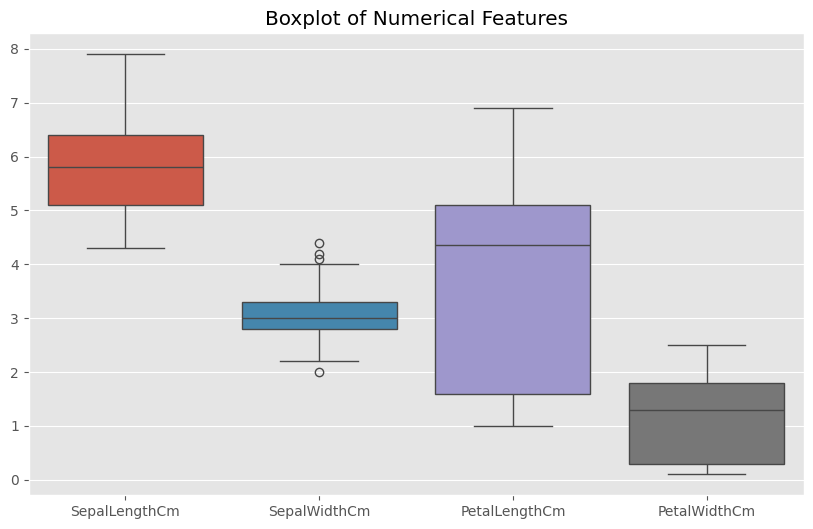

In [15]:
numerical_cols = ["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]

plt.figure(figsize=(10,6))

sns.boxplot(data=df[numerical_cols])

plt.title("Boxplot of Numerical Features")
plt.show()

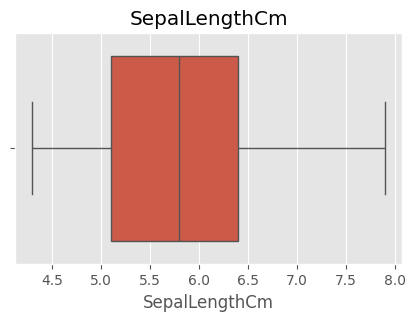

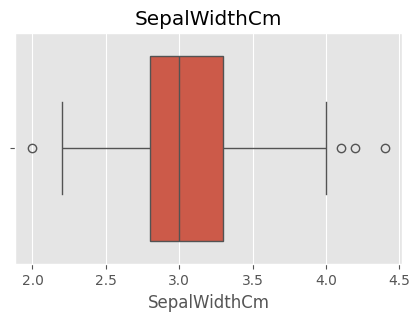

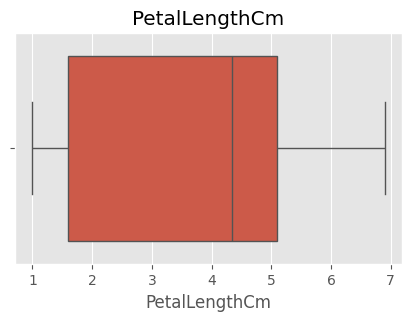

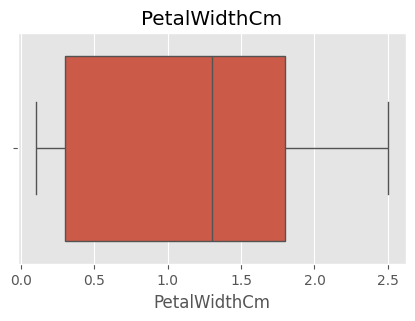

In [16]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Outlier Detection & Treatment

Boxplots were used to identify potential outliers in the numerical features. A small number of outliers were observed in the SepalWidthCm feature, while the remaining features showed little or no evidence of outliers. Since these values represent natural biological variation rather than data entry errors, no outliers were removed or capped. All observations were retained to preserve the integrity of the dataset.

In [17]:
df = df.drop("Id", axis=1)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# Removing Irrelevant Feature

The Id column was removed because it is a unique identifier and does not contribute to predicting the target variable (Species).
Removing unnecessary features helps improve model efficiency and prevents irrelevant information from influencing the machine learning model.

In [18]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [19]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Label Encoding

The Species column is the target variable and contains three categorical classes. Label Encoding was applied to convert these categories into numerical values (0, 1, and 2), making the target variable suitable for machine learning algorithms.

Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.900681,1.032057,-1.341272,-1.312977,0
1,-1.143017,-0.124958,-1.341272,-1.312977,0
2,-1.385353,0.337848,-1.398138,-1.312977,0
3,-1.506521,0.106445,-1.284407,-1.312977,0
4,-1.021849,1.263460,-1.341272,-1.312977,0


# Feature Scaling

StandardScaler was applied to the numerical features to standardize their values. This technique transforms the data to have a mean of 0 and a standard deviation of 1. Feature scaling is important because it ensures that all numerical features contribute equally during machine learning model training and prevents features with larger values from dominating the learning process.

In [21]:
df.to_csv("Cleaned_Iris_Dataset.csv", index=False)

In [22]:
from google.colab import files

files.download("Cleaned_Iris_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Exploratory Data Analysis (EDA)

<Figure size 1200x800 with 0 Axes>

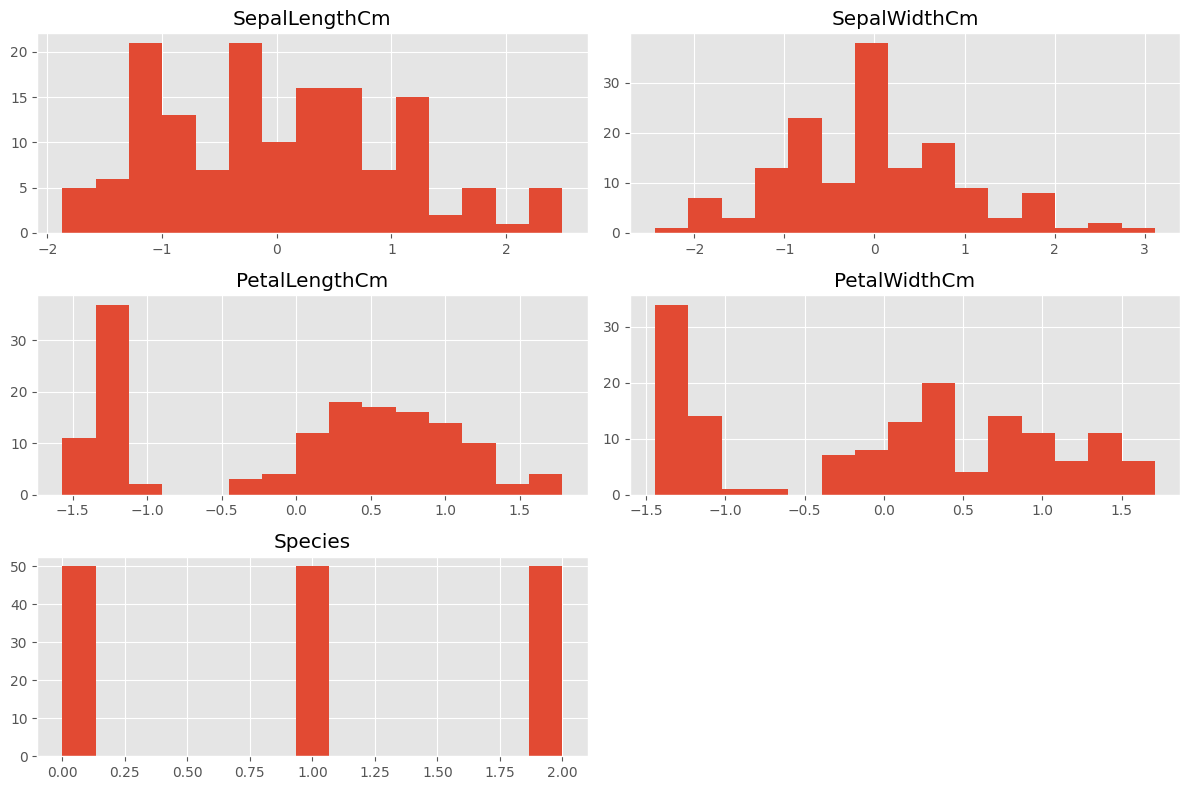

In [23]:
# Histograms
plt.figure(figsize=(12,8))

df.hist(figsize=(12,8), bins=15)

plt.tight_layout()
plt.show()

# Histogram Analysis

Histograms were used to examine the distribution of each numerical feature in the Iris dataset. SepalWidthCm approximately follows a normal (bell-shaped) distribution, with most observations clustered around the center. SepalLengthCm shows a wider spread of values. PetalLengthCm and PetalWidthCm display a bimodal distribution, indicating that the flower species differ significantly in their petal measurements. This suggests that petal-related features are likely to be highly informative for species classification.

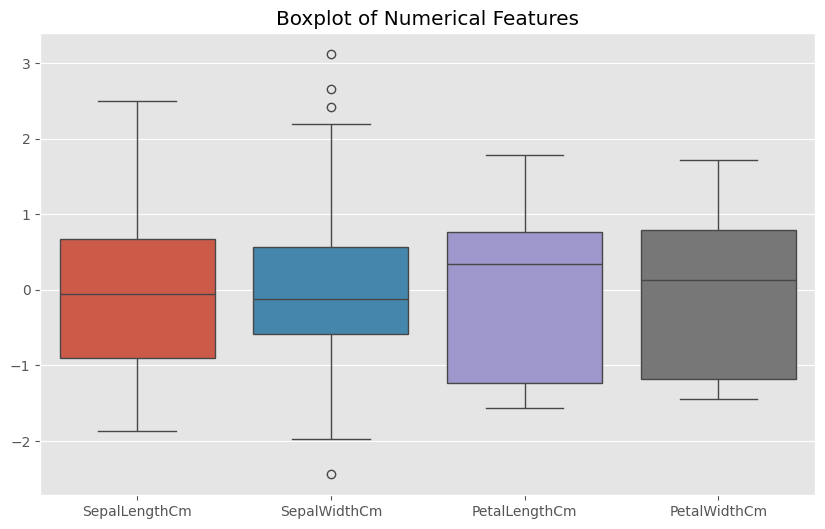

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[["SepalLengthCm",
                     "SepalWidthCm",
                     "PetalLengthCm",
                     "PetalWidthCm"]])

plt.title("Boxplot of Numerical Features")
plt.show()

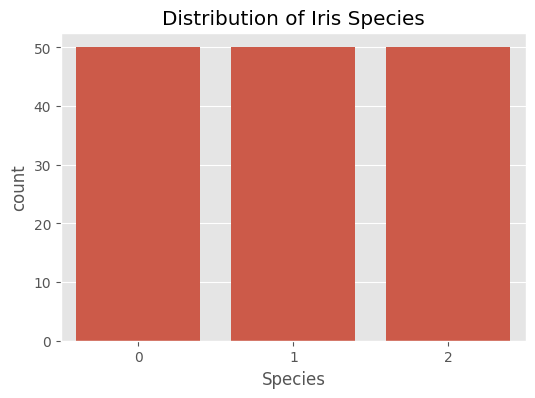

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x="Species", data=df)

plt.title("Distribution of Iris Species")

plt.show()

# Count Plot Analysis

The count plot shows that all three Iris species are equally represented in the dataset, with 50 samples for each class. This indicates that the dataset is balanced, which is beneficial for training unbiased machine learning models.

In [26]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02,150.000000
mean,-4.736952e-16,-6.631732e-16,3.315866e-16,-2.842171e-16,1.000000
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00,0.819232
min,-1.870024e+00,-2.438987e+00,-1.568735e+00,-1.444450e+00,0.000000
25%,-9.006812e-01,-5.877635e-01,-1.227541e+00,-1.181504e+00,0.000000
50%,-5.250608e-02,-1.249576e-01,3.362659e-01,1.332259e-01,1.000000
75%,6.745011e-01,5.692513e-01,7.627586e-01,7.905908e-01,2.000000
max,2.492019e+00,3.114684e+00,1.786341e+00,1.710902e+00,2.000000


The numerical features were analyzed using histograms, boxplots, and summary statistics. Petal Length and Petal Width showed greater variation than the sepal measurements. The distributions were generally well balanced, with slight skewness in some features. The count plot confirmed that all three Iris species are equally represented in the dataset, making it balanced for machine learning tasks.

Bivariate Analysis

##1. Petal Length vs Petal Width (Colored by Species)

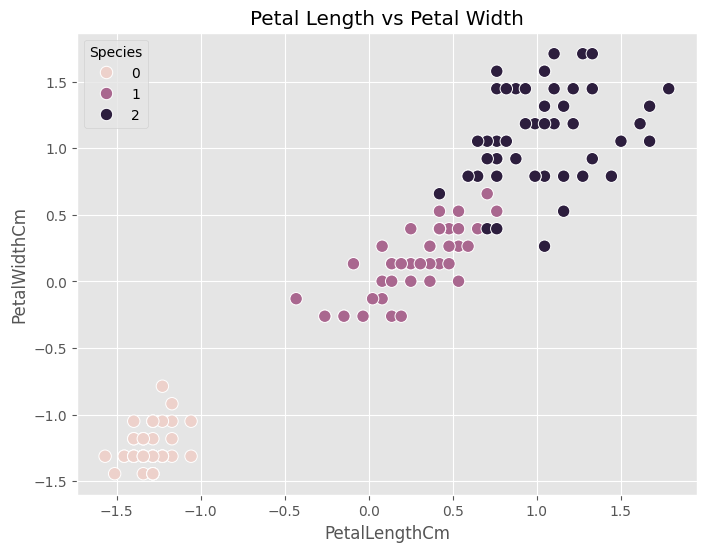

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=80
)

plt.title("Petal Length vs Petal Width")
plt.show()

Observation

The scatter plot reveals a strong positive relationship between PetalLengthCm and PetalWidthCm. As petal length increases, petal width also tends to increase. The three Iris species form distinct clusters, with Species 0 having the smallest petals, Species 1 having medium-sized petals, and Species 2 having the largest petals. This clear separation indicates that petal measurements are highly effective features for distinguishing flower species.

#2. Sepal Length vs Sepal Width

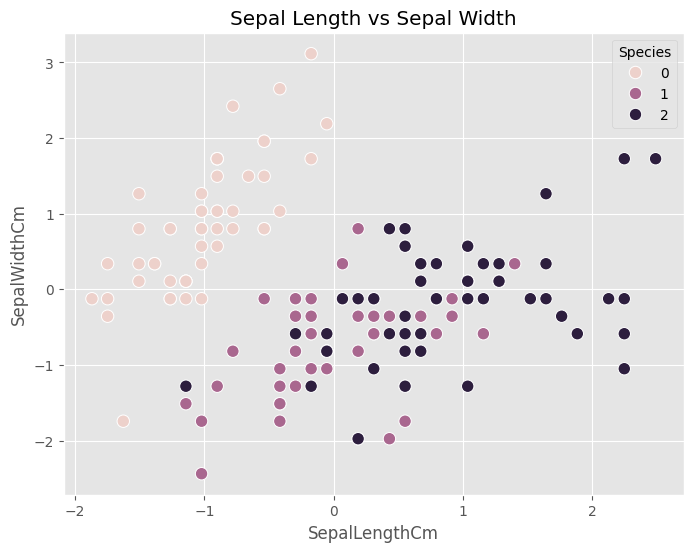

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species",
    s=80
)

plt.title("Sepal Length vs Sepal Width")
plt.show()

Observation

The scatter plot of SepalLengthCm versus SepalWidthCm shows a weaker relationship compared to the petal features. Although Species 0 forms a relatively distinct cluster, Species 1 and Species 2 overlap considerably. This overlap indicates that sepal measurements alone are less effective for distinguishing flower species.

#3. Grouped Statistics

In [29]:
df.groupby("Species").mean()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
0,-1.014579,0.842307,-1.304878,-1.255129
1,0.112282,-0.657184,0.285087,0.167409
2,0.902297,-0.185122,1.019792,1.087720


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954,0.782561
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757,0.949043
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000,0.956464
Species,0.782561,-0.419446,0.949043,0.956464,1.000000


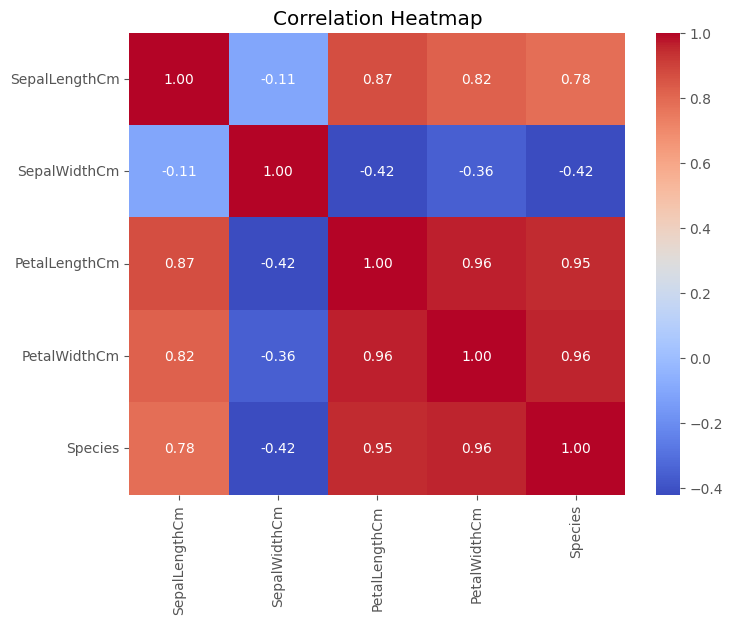

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

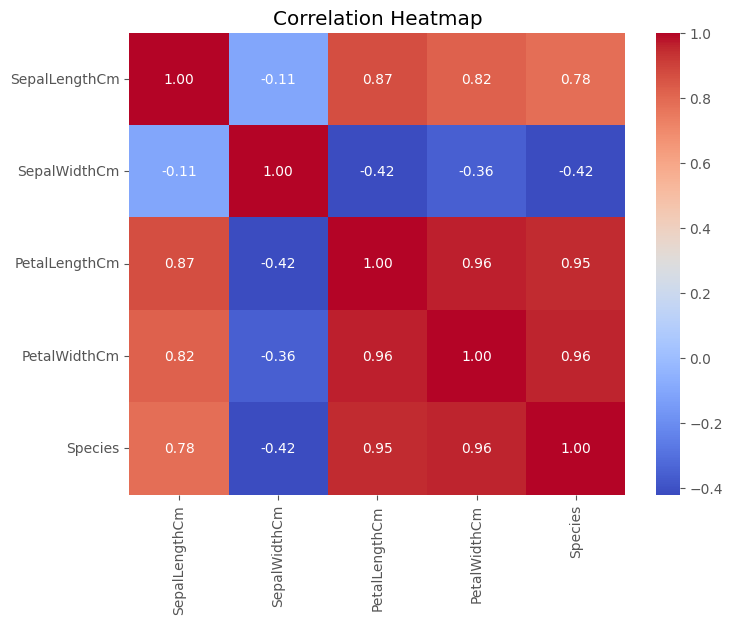

In [32]:
corr = df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation Analysis

The correlation heatmap was generated to examine the relationships among the numerical features in the Iris dataset. It shows that PetalLengthCm and PetalWidthCm have a strong positive correlation, indicating that longer petals generally have greater widths. SepalLengthCm also has a positive relationship with petal measurements, while SepalWidthCm shows weaker and, in some cases, negative relationships with the other features. These patterns suggest that petal measurements are the most informative features for distinguishing Iris species.

The correlation heatmap was used to examine the relationships among the numerical features in the Iris dataset. It shows that PetalLengthCm and PetalWidthCm have the strongest positive correlation, indicating that flowers with longer petals generally have wider petals. SepalLengthCm also has a positive relationship with petal measurements, while SepalWidthCm exhibits weaker correlations with the remaining features. These results suggest that petal-related features are the most informative variables for distinguishing Iris flower species.

# Machine Learning Preparation Summary

1. Missing Value Treatment: No missing values were found; therefore, no imputation was required.

2. Duplicate Records: No duplicate records were identified, so no records were removed.

3. Outlier Treatment: A few outliers were observed in SepalWidthCm. These values were retained because they represent natural biological variation rather than data entry errors.

4. Encoding Technique: The Species column was converted into numerical values using Label Encoding.

5. Feature Scaling: StandardScaler was applied to all numerical features to standardize their values and improve compatibility with machine learning algorithms.

6. Important Features: PetalLengthCm and PetalWidthCm were identified as the most informative features for predicting the flower species based on the exploratory data analysis and correlation analysis.

7. Machine Learning Readiness: The dataset has been cleaned, encoded, standardized, and thoroughly analyzed. It is now ready for machine learning model development.

# Key Insights (Required in the Report)
1. The Iris dataset contains 150 observations and is balanced across three flower species.
2. The dataset has no missing values and no duplicate records, making it high quality.
3. PetalLengthCm and PetalWidthCm are the strongest features for distinguishing flower species.
4. SepalWidthCm contains a few natural outliers, which were retained because they represent valid biological variation.
5. The dataset has been successfully preprocessed through feature selection, label encoding, and standard scaling, making it ready for machine learning model development.